# Minhash

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasketch import MinHash, MinHashLSH

In [34]:
def discretise(spread_window, z_threshold=1.0):
    mean = spread_window.mean()
    std  = spread_window.std()
    z    = (spread_window - mean) / std
    
    symbols = []
    for val in z:
        if val < -1.5:       symbols.append('--')
        elif val < -0.3:     symbols.append('-')
        elif val <  0.3:     symbols.append('0')
        elif val <  1.5:     symbols.append('+')
        else:                symbols.append('++')
    return symbols

In [35]:
def shingle(symbols, k=3):
    return set(''.join(symbols[i:i+k]) for i in range(len(symbols) - k + 1))

In [36]:
df = pd.read_csv('../data/manipulated/spreads/HPQ_WY.csv', index_col=0, parse_dates=True)

window = df['spread'].iloc[:20]
symbols = discretise(window)
shingles = shingle(symbols)

print(symbols)
print(shingles)

['-', '-', '-', '-', '--', '+', '-', '0', '0', '++', '-', '+', '+', '-', '-', '-', '+', '++', '+', '+']
{'-+++', '+--', '++++', '----', '++-', '-00', '---', '-++', '++-+', '+-0', '---+', '00++', '--+-', '--+', '0++-'}


/tmp/ipykernel_85524/2862638244.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv('../data/manipulated/spreads/HPQ_WY.csv', index_col=0, parse_dates=True)


In [37]:
def make_minhash(shingles, num_perm=128):
    m = MinHash(num_perm=num_perm)
    for s in shingles:
        m.update(s.encode('utf-8'))
    return m

In [38]:
m = make_minhash(shingles)
print(m.hashvalues[:5]) 

[126663100 278506959 814761028  68307151 258205348]


In [39]:
WINDOW_SIZE = 20

def build_lsh_index(spread, window_size=WINDOW_SIZE, num_perm=128):
    lsh = MinHashLSH(threshold=0.5, num_perm=num_perm)
    signatures = {}
    
    for i in range(len(spread) - window_size):
        window = spread.iloc[i:i + window_size]
        symbols = discretise(window)
        shingles = shingle(symbols)
        m = make_minhash(shingles)
        key = f"w_{i}"
        lsh.insert(key, m)
        signatures[key] = (m, i)  # store signature and start index for forward return lookup
    
    return lsh, signatures

In [40]:
spread = df['spread']
lsh, signatures = build_lsh_index(spread)
print(f"indexed {len(signatures)} windows")

indexed 2367 windows


In [41]:
def minhash_signal(spread, lsh, signatures, window_size=WINDOW_SIZE, forward_days=10, num_perm=128):
    # current window = last window_size days
    current_window = spread.iloc[-window_size:]
    symbols = discretise(current_window)
    shingles = shingle(symbols)
    query_m = make_minhash(shingles)
    
    similar_keys = lsh.query(query_m)
    
    if not similar_keys:
        return 0  # no similar windows found, no confirmation
    
    # compute forward return for each similar historical window
    forward_returns = []
    for key in similar_keys:
        _, start_idx = signatures[key]
        end_idx = start_idx + window_size + forward_days
        if end_idx < len(spread):
            forward_return = spread.iloc[start_idx + window_size + forward_days] - spread.iloc[start_idx + window_size]
            forward_returns.append(forward_return)
    
    if not forward_returns:
        return 0
    
    avg_forward_return = np.mean(forward_returns)
    return avg_forward_return

In [42]:
signal = minhash_signal(spread, lsh, signatures)
print(f"MinHash signal: {signal:.4f}")

MinHash signal: -0.0253


In [ ]:
def combine_signals(gmm_signal, minhash_signal):
    if gmm_signal == 0:
        return 0
    # confirm if minhash agrees in direction, suppress if it disagrees
    if gmm_signal == 1 and minhash_signal > 0:
        return 1
    if gmm_signal == -1 and minhash_signal < 0:
        return -1
    return 0  # disagreement, so stay flat

In [44]:
print(combine_signals(1,  0.05))   # should be  1 — confirmed long
print(combine_signals(1,  -0.05))  # should be  0 — suppressed
print(combine_signals(-1, -0.05))  # should be -1 — confirmed short
print(combine_signals(0,  -0.05))  # should be  0 — no GMM signal

1
0
-1
0


In [45]:
def compute_minhash_signals(spread, gmm_signals, lsh, signatures, window_size=WINDOW_SIZE, forward_days=10):
    minhash_signals = pd.Series(0.0, index=spread.index)
    
    # only query on days where GMM signal is non-zero
    signal_days = gmm_signals[gmm_signals != 0].index
    
    for date in signal_days:
        i = spread.index.get_loc(date)
        if i < window_size:
            continue
        
        window = spread.iloc[i - window_size:i]
        symbols = discretise(window)
        shingles = shingle(symbols)
        query_m = make_minhash(shingles)
        
        similar_keys = lsh.query(query_m)
        if not similar_keys:
            continue
        
        forward_returns = []
        for key in similar_keys:
            _, start_idx = signatures[key]
            end_idx = start_idx + window_size + forward_days
            if end_idx < len(spread) and start_idx + window_size <= i:
                fwd = spread.iloc[start_idx + window_size + forward_days] - spread.iloc[start_idx + window_size]
                forward_returns.append(fwd)
        
        if forward_returns:
            minhash_signals.loc[date] = np.mean(forward_returns)
    
    return minhash_signals

In [46]:
cointegration_pairs = pd.read_csv('../data/manipulated/cointegrated_pairs.csv')

In [47]:
MIN_SIGNALS = 200  # minimum number of non-zero GMM signals to keep a pair

active_pairs = []

for _, row in cointegration_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    filename = f"../data/manipulated/spreads/{a}_{b}.csv"
    df = pd.read_csv(filename, index_col=0, parse_dates=True, date_format='%Y-%m-%d')
    
    n_signals = (df['signal'] != 0).sum()
    if n_signals >= MIN_SIGNALS:
        active_pairs.append(row)
        print(f"{a}/{b} — {n_signals} signals, keeping")
    else:
        print(f"{a}/{b} — {n_signals} signals, dropping")

active_pairs = pd.DataFrame(active_pairs)
print(f"\n{len(active_pairs)} pairs kept from {len(cointegration_pairs)}")

HPQ/WY — 130 signals, dropping
HPQ/KKR — 115 signals, dropping
FTV/AVY — 1 signals, dropping
HPQ/SBUX — 186 signals, dropping
KKR/AVY — 211 signals, keeping
KKR/SBUX — 416 signals, keeping
CDW/CSX — 233 signals, keeping
CTSH/NSC — 219 signals, keeping
CTSH/CSX — 197 signals, dropping
CTSH/AVY — 180 signals, dropping
CTSH/UNP — 196 signals, dropping
CTSH/AMCR — 235 signals, keeping
CBRE/SBUX — 314 signals, keeping
CTSH/HON — 204 signals, keeping
CTSH/LIN — 180 signals, dropping
NSC/SBUX — 152 signals, dropping
FFIV/AVY — 238 signals, keeping
FFIV/SBUX — 186 signals, dropping
HAS/FTV — 77 signals, dropping
HAS/SBUX — 142 signals, dropping
HON/BLK — 0 signals, dropping
HON/ECL — 99 signals, dropping
HAS/KKR — 162 signals, dropping
NWS/CRH — 15 signals, dropping
HAS/UNP — 103 signals, dropping
FFIV/HPQ — 227 signals, keeping
FFIV/TEL — 254 signals, keeping
FFIV/NWS — 226 signals, keeping
HAS/NSC — 162 signals, dropping
HAS/HPQ — 82 signals, dropping
HAS/TEL — 237 signals, keeping
HAS/NWS —

In [48]:
for _, row in active_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    filename = f"../data/manipulated/spreads/{a}_{b}.csv"
    df = pd.read_csv(filename, index_col=0, parse_dates=True, date_format='%Y-%m-%d')
    
    spread = df['spread']
    lsh, signatures = build_lsh_index(spread)
    minhash_signals = compute_minhash_signals(spread, df['signal'], lsh, signatures)
    
    df['minhash_signal'] = minhash_signals
    df['final_signal'] = df.apply(
        lambda r: combine_signals(r['signal'], r['minhash_signal']), axis=1
    )
    
    df.to_csv(filename)
    print(f"done: {a}/{b}")

done: KKR/AVY
done: KKR/SBUX
done: CDW/CSX
done: CTSH/NSC
done: CTSH/AMCR
done: CBRE/SBUX
done: CTSH/HON
done: FFIV/AVY
done: FFIV/HPQ
done: FFIV/TEL
done: FFIV/NWS
done: HAS/TEL
done: FFIV/UNP
done: CBRE/HAS
done: FFIV/HAS
done: FFIV/NSC
done: FFIV/FTV
done: HON/AMCR
done: GRMN/AMCR
done: GRMN/HAS
done: NWS/KKR
done: TEL/KKR
done: TRMB/TEL
done: GRMN/AVY
done: TRMB/WY
done: BLK/NSC
done: AMCR/KKR
done: AMCR/WY
done: BLK/AVY
done: BLK/CSX
done: TRMB/SBUX
done: NWS/SBUX
done: CRH/SBUX
done: CSX/UNP
done: CSX/NSC
done: TRMB/HAS
done: CDW/NSC
done: CDW/WY
done: CDW/HON
done: KKR/FTV
done: CDW/UNP
done: CDW/NWS
done: CDW/SBUX
done: NSC/FTV
done: LIN/AVY
done: UNP/NSC
done: CTSH/WY
done: LIN/CSX
done: LIN/AMCR
done: LIN/WY
done: BLK/AMCR
done: LIN/UNP
done: FFIV/WY
done: CDW/CBRE
done: CTSH/KKR
done: UNP/AVY
done: CTSH/NWS
done: APD/NSC
done: LIN/NWS
done: HON/FFIV
done: CTSH/TRMB
done: APD/KKR
done: HON/CRH
done: LIN/KKR
done: HON/FTV
done: HON/KKR
done: CTSH/GRMN
done: CTSH/APD
done: UNP/

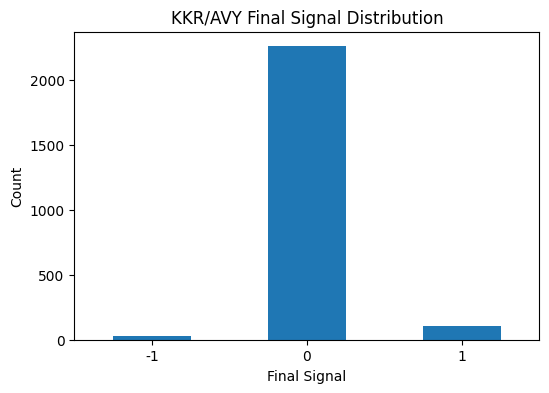

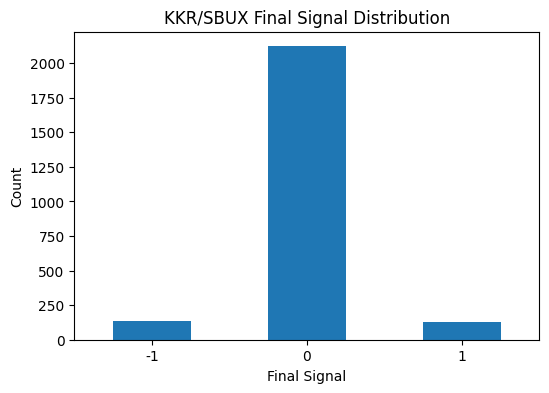

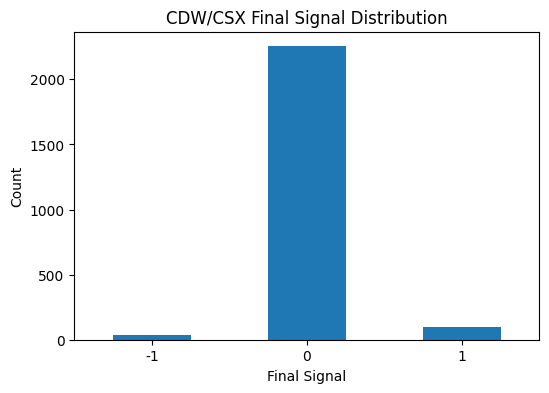

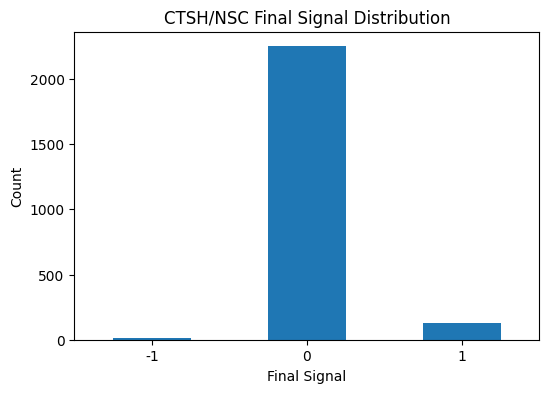

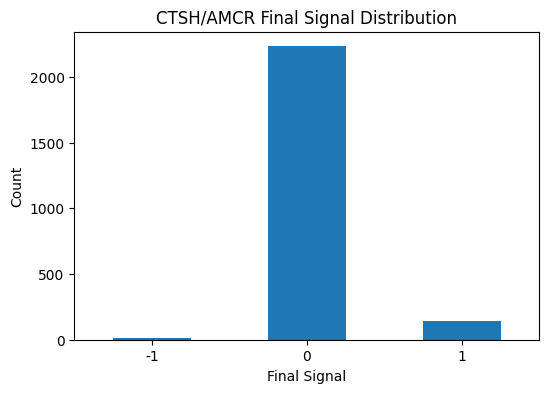

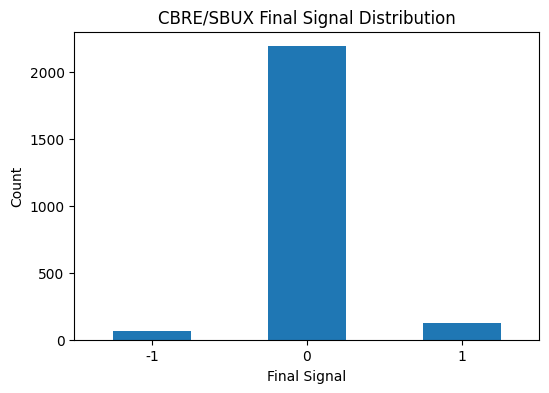

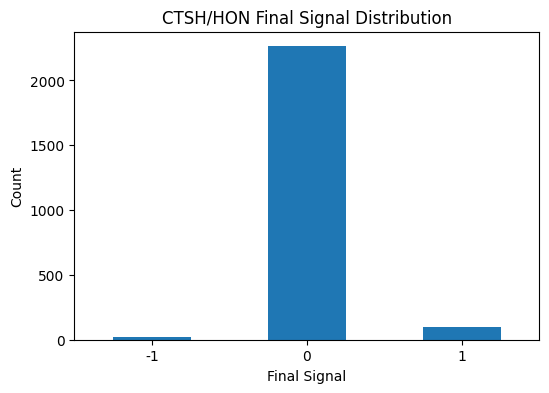

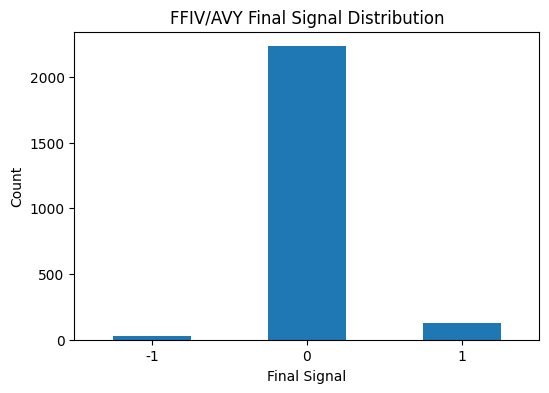

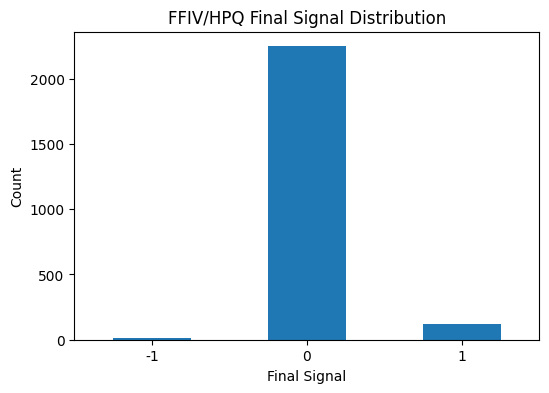

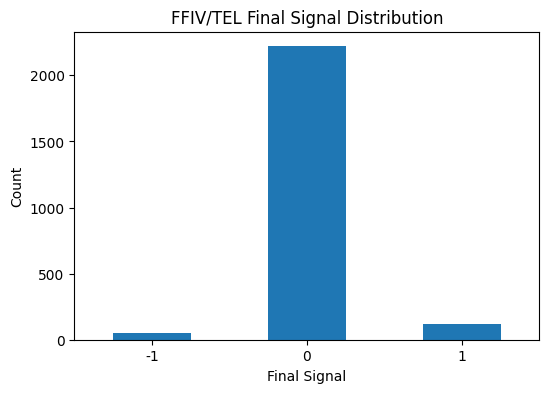

In [50]:
# plot first 10 final signal distributions
for _, row in active_pairs.head(10).iterrows():
    a, b = row['asset_a'], row['asset_b']
    filename = f"../data/manipulated/spreads/{a}_{b}.csv"
    df = pd.read_csv(filename, index_col=0, parse_dates=True, date_format='%Y-%m-%d')
    
    plt.figure(figsize=(6, 4))
    df['final_signal'].value_counts().sort_index().plot(kind='bar')
    plt.title(f"{a}/{b} Final Signal Distribution")
    plt.xlabel('Final Signal')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()

From first ten pairs, we see that we are not trading an overwhelming majority of the time and may be slightly biased towards long trades.